<style>
    /* we can use injections to style the resulting pdf */

    /* wrapping */
    pre, .jp-CodeCell .jp-Editor {
        display: block!important;
    }
    .jp-Cell-inputArea pre {
           page-break-inside: avoid !important;
    }
    .cm-editor.cm-s-jupyter .highlight pre {
        white-space: pre-wrap !important;
    }

    /* margins */
    div#notebook-container,
    div.container,
    div#notebook,
    .jp-Notebook {
        max-width: none !important;
        width: 102.6% !important;
        margin-left: -2.6% !important;
        padding: 0 !important;
    }
    .jp-MarkdownCell {
        margin-left: -6px;
        margin-bottom: 8px;
        margin-top: 12px;
    }
    .jp-OutputArea .jp-RenderedText {
        padding-left: calc(1ch + 16px);
        padding-top: 4px;
        padding-bottom: 8px;
    }
</style>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm import tqdm
from joblib import Parallel, delayed
import re
import unicodedata
from lingua import Language, LanguageDetectorBuilder
from gensim.models import Word2Vec, Phrases
from gensim.models.phrases import Phraser
import gensim
import statsmodels.formula.api as smf

In [2]:
# final df versions from the qc (i.e. with body_normalized for comments)

In [3]:
comments_df = pd.read_parquet('qc_comments_df.parquet')

In [4]:
submissions_df = pd.read_parquet('qc_submissions_df.parquet')

In [5]:
author_stats_df = pd.read_parquet('author_stats_df.parquet')

In [6]:
print(f"Date range: {comments_df['created_utc'].min()} to {comments_df['created_utc'].max()}")

Date range: 2022-12-01 00:00:05 to 2025-04-30 23:59:49


In [7]:
comments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5993752 entries, 0 to 5993751
Data columns (total 13 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                object        
 1   link_id           object        
 2   parent_id         object        
 3   created_utc       datetime64[ns]
 4   author            object        
 5   subreddit         object        
 6   body              object        
 7   score             int64         
 8   controversiality  int64         
 9   distinguished     object        
 10  text_status       object        
 11  body_normalized   object        
 12  date              object        
dtypes: datetime64[ns](1), int64(2), object(10)
memory usage: 594.5+ MB


In [8]:
submissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606896 entries, 0 to 606895
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   id                   606896 non-null  object        
 1   created_utc          606896 non-null  datetime64[ns]
 2   author               606896 non-null  object        
 3   subreddit            606896 non-null  object        
 4   title                606896 non-null  object        
 5   selftext             606896 non-null  object        
 6   score                606896 non-null  int64         
 7   upvote_ratio         606896 non-null  float64       
 8   link_flair_text      606896 non-null  object        
 9   domain               606896 non-null  object        
 10  distinguished        606896 non-null  object        
 11  num_comments         606896 non-null  int64         
 12  over_18              606896 non-null  bool          
 13  url           

In [9]:
author_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 751659 entries, ------------------16 to zzzzzzzzzzzzzzz69
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   comment_count                751659 non-null  int64  
 1   unique_normalized_count      751659 non-null  int64  
 2   normalized_uniqueness_ratio  751659 non-null  float64
 3   top_signature_count          8780 non-null    float64
 4   num_signatures_found         751659 non-null  float64
 5   has_signature                751659 non-null  bool   
 6   signature_consistency        751659 non-null  float64
 7   signature_prevalence_ratio   751659 non-null  float64
 8   tfidf_similarity             95800 non-null   float64
 9   is_in_bot_name_list          751659 non-null  bool   
 10  is_declared_bot              751659 non-null  bool   
 11  author_type                  751659 non-null  object 
dtypes: bool(3), float64(6), int64(2),

In [10]:
# 1. DISTRIBUTIONS

In [11]:
comments_df["body_len"] = comments_df["body"].astype(str).str.len()
desc = comments_df["body_len"].describe(percentiles=[.10, .15, .20, .25, .5, .75, .90, .95, .99])
desc.apply(lambda x: f"{x:.2f}")

count    5993752.00
mean         202.14
std          353.54
min            0.00
10%            9.00
15%           17.00
20%           25.00
25%           33.00
50%           92.00
75%          213.00
90%          505.00
95%          797.00
99%         1605.00
max        10049.00
Name: body_len, dtype: object

In [12]:
submissions_df["title_len"] = submissions_df["title"].astype(str).str.len()
desc = submissions_df["title_len"].describe(percentiles=[.10, .15, .20, .25, .5, .75, .90, .95, .99])
desc.apply(lambda x: f"{x:.2f}")

count    606896.00
mean         46.22
std          38.57
min           0.00
10%          12.00
15%          15.00
20%          18.00
25%          21.00
50%          37.00
75%          60.00
90%          89.00
95%         114.00
99%         207.00
max         303.00
Name: title_len, dtype: object

In [13]:
submissions_df_go = submissions_df[submissions_df['text_status'] == 'available']
submissions_df_go["selftext_len"] = submissions_df_go["selftext"].astype(str).str.len()
desc = submissions_df_go["selftext_len"].describe(percentiles=[.10, .15, .20, .25, .5, .75, .90, .95, .99])
desc.apply(lambda x: f"{x:.2f}")

C:\Users\windo\AppData\Local\Temp\ipykernel_1544\3503642734.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submissions_df_go["selftext_len"] = submissions_df_go["selftext"].astype(str).str.len()


count    284223.00
mean        582.73
std        1275.56
min           1.00
10%          40.00
15%          59.00
20%          81.00
25%         107.00
50%         264.00
75%         626.00
90%        1317.00
95%        2065.00
99%        4763.00
max      191760.00
Name: selftext_len, dtype: object

In [14]:
# 1. LANGUAGE IDENTIFICATION

In [15]:
BATCH_SIZE = 10000
N_JOBS = -1
MIN_CHAR_LENGTH = 33  # body_len 25th percentile

In [16]:
# we use a global variable for the worker process
_worker_detector = None

def get_worker_detector():
    global _worker_detector
    if _worker_detector is None:
        languages = [
            Language.ENGLISH, Language.FRENCH, Language.GERMAN, Language.SPANISH,
            Language.RUSSIAN, Language.CHINESE, Language.JAPANESE, Language.PORTUGUESE,
            Language.ITALIAN, Language.DUTCH, Language.INDONESIAN, Language.VIETNAMESE,
            Language.ARABIC, Language.PERSIAN, Language.TURKISH
        ]
        _worker_detector = LanguageDetectorBuilder.from_languages(*languages).build()
    return _worker_detector

In [17]:
# common in English but rare in the other languages above
ENGLISH_EXCLUSIVE_STOPWORDS = {
    'the', 'and', 'that', 'have', 'with', 'this', 'but', 'from',
    'not', 'what', 'when', 'your', 'like', 'just', 'which', 'there',
    'about', 'would', 'could', 'should', 'some', 'think'
}

# if a comment contains these, it's valid for research regardless of grammar
DOMAIN_KEYWORDS = {
    'llm', 'gpu', 'cpu', 'ram', 'vram', 'llama', 'mistral', 'mixtral',
    'gpt', 'claude', 'quant', 'gguf', 'exl2', 'ai', 'bot', 'model',
    'token', 'parameter', '7b', '13b', '70b', '8b', '4090', '3090',
    'nsfw', 'python', 'code', 'error', 'bug', 'dataset', 'lora'
}

In [18]:
def super_clean_text(text):
    if not isinstance(text, str): return ""

    # NFKC decomposition (zalgo/diacritics)
    text = unicodedata.normalize('NFKC', text)

    # we allow Lo for Persian/Chinese, Mn needed for some Arabic/Persian accents
    allowed_cats = {'Ll', 'Lu', 'Nd', 'Zs', 'Lo', 'Mn'}
    text = "".join([c for c in text if unicodedata.category(c) in allowed_cats])

    # standard clean
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # laughter/screaming normalization
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return " ".join(text.split())

def detect_with_heuristics(text):
    # metadata/deleted
    if not isinstance(text, str): return 'unknown', 0.0, 'empty'

    cleaned = super_clean_text(text)

    # symbols/emojis
    if not cleaned and text.strip():
        return 'unknown', 0.0, 'emoji_symbol_only'
    if not cleaned:
        return 'unknown', 0.0, 'empty'

    tokens = cleaned.split()

    # basic repetition filter (if > 10 words and unique ratio < 10%)
    if len(tokens) > 10:
        unique_ratio = len(set(tokens)) / len(tokens)
        if unique_ratio < 0.1:
            return 'unknown', 0.0, 'spam/keysmash'

    # domain keywords
    if len(set(tokens).intersection(DOMAIN_KEYWORDS)) >= 1:
        return 'en', 1.0, 'domain_keyword'

    # english stopwords
    if len(set(tokens).intersection(ENGLISH_EXCLUSIVE_STOPWORDS)) >= 2:
        return 'en', 1.0, 'english_stopword'

    # length threshold
    if len(cleaned) < MIN_CHAR_LENGTH:
        return 'unknown', 0.0, 'too_short'

    try:
        detector = get_worker_detector()
        confidence_values = detector.compute_language_confidence_values(cleaned)

        if not confidence_values:
            return 'unknown', 0.0, 'error'

        target = confidence_values[0]
        lang_code = target.language.iso_code_639_1.name.lower()
        confidence = target.value

        # egyptian script and, in general, any special characters are thrown into ar with zero confidence
        # all keysmashes are placed in vi
        if lang_code in ['vi', 'ar'] and confidence < 0.85:
             return 'unknown', confidence, 'spam/keysmash'

        if confidence > 0.85:
            return lang_code, confidence, 'high_confidence'
        elif lang_code == 'en' and confidence > 0.35:
            return 'en', confidence, 'low_conf_en'
        else:
            return lang_code, confidence, 'low_confidence'

    except Exception:
        return 'unknown', 0.0, 'error'

In [19]:
def process_batch_lingua(text_list):
    # runs on the worker, processes a whole batch using the cached detector
    return [detect_with_heuristics(t) for t in text_list]

In [20]:
mask_com_valid = comments_df['text_status'] == 'available'
comments_to_process = comments_df.loc[mask_com_valid, 'body_normalized'].fillna(
    comments_df.loc[mask_com_valid, 'body']
).fillna("").astype(str).tolist()

In [21]:
# titles and selftexts don't have a normalized version, we can assume
# raw text is fine for submissions as they have fewer tags
mask_sub_valid = submissions_df['text_status'] == 'available'
submissions_to_process = (
    submissions_df.loc[mask_sub_valid, 'title'].fillna("") + " " +
    submissions_df.loc[mask_sub_valid, 'selftext'].fillna("")
).astype(str).tolist()

In [22]:
print(f"{len(comments_to_process)} items")
comment_chunks = [comments_to_process[i:i + BATCH_SIZE] for i in range(0, len(comments_to_process), BATCH_SIZE)]

comment_results = Parallel(n_jobs=N_JOBS)(
        delayed(process_batch_lingua)(chunk)
        for chunk in tqdm(comment_chunks, desc="Lingua Detection")
)
comment_results_flat = [item for sublist in comment_results for item in sublist]

5642738 items


Lingua Detection: 100%|██████████| 565/565 [00:31<00:00, 18.15it/s]


In [23]:
print(f"{len(submissions_to_process)} items")
sub_chunks = [submissions_to_process[i:i + BATCH_SIZE] for i in range(0, len(submissions_to_process), BATCH_SIZE)]

sub_results = Parallel(n_jobs=N_JOBS)(
    delayed(process_batch_lingua)(chunk)
    for chunk in tqdm(sub_chunks, desc="Submissions V4")
)
sub_results_flat = [item for sublist in sub_results for item in sublist]

284223 items


Submissions V4: 100%|██████████| 29/29 [00:00<00:00, 1277.69it/s]


In [24]:
langs, confs, statuses = zip(*comment_results_flat)
comments_df.loc[mask_com_valid, 'lang'] = langs
comments_df.loc[mask_com_valid, 'lang_conf'] = confs
comments_df.loc[mask_com_valid, 'lang_status'] = statuses

In [25]:
langs_s, confs_s, statuses_s = zip(*sub_results_flat)
submissions_df.loc[mask_sub_valid, 'lang'] = langs_s
submissions_df.loc[mask_sub_valid, 'lang_conf'] = confs_s
submissions_df.loc[mask_sub_valid, 'lang_status'] = statuses_s

In [26]:
print("Comment language status distribution:")
print(comments_df.loc[mask_com_valid, 'lang_status'].value_counts(normalize=True))

Comment language status distribution:
lang_status
english_stopword     0.422777
too_short            0.235133
domain_keyword       0.176679
high_confidence      0.088276
low_conf_en          0.067915
low_confidence       0.004725
emoji_symbol_only    0.004365
spam/keysmash        0.000130
Name: proportion, dtype: float64


In [27]:
print("Top language (comments):")
print(comments_df.loc[mask_com_valid, 'lang'].value_counts())

Top language (comments):
lang
en         4274375
unknown    1352158
nl            5879
de            3749
fr            1760
es            1287
it             857
pt             735
id             727
tr             608
ru             416
ja              58
zh              40
vi              38
ar              32
fa              19
Name: count, dtype: int64


In [28]:
print(comments_df[comments_df['lang_status'] == 'low_confidence'][['body', 'lang', 'lang_conf']].head(10))

                                                   body lang  lang_conf
72    4'33" by John Cage 😎  I can listen to that all...   en   0.273340
519                Kudos and comment on Alpha Centauri.   fr   0.298680
795                 I don’t do online and I don’t drink   en   0.325746
1106                I’m lazy and I can’t write for shit   en   0.324286
1613             Epic premise and plot, decent grammar.   en   0.288263
1695   Oh, just for fun, give me a list of them. go on.   en   0.340779
2012            Wall of text is an instant nope from me   en   0.338627
2255   A multifandom multiverse is a type of crossover.   en   0.250561
2424  Myslel jsem spíš friends, tak jestli bys chtěl...   tr   0.440555
2544                I do love me a manipulative bastard   en   0.267286


In [29]:
print(comments_df[
    (comments_df['lang'] != 'en') &
    (comments_df['lang_status'] == 'high_confidence')
][['body', 'lang', 'lang_conf']].sample(10, random_state=1))

                                                      body lang  lang_conf
2180944  Muito obrigado, meu amigo! Eu adoraria ver uma...   pt   0.960305
4941988  Tamo en eso, no esperes respuesta tan pronto p...   es   0.955562
200690   Félicitations! C’est le futur. Mais, au mois d...   fr   0.995296
5542863  ¿Alguien me puede comentar cómo comenzó a prof...   es   0.999945
14595    جوابه درست بده نمیدونم چیه چرا هنوز گیر دادید ...   fa   0.999987
4747790              у меня до сих пор не работает без впн   ru   1.000000
891303   Это типо, Саша Наумов, это к этому отсылка нах...   ru   1.000000
5613350  merci! super intéressant. J'ai juste une petit...   fr   1.000000
140240   También es una buena idea , pero les conviene ...   es   1.000000
1276406  En effet ce n'est pas un moteur de faits mais ...   fr   1.000000


In [30]:
print(comments_df[comments_df['lang'] == 'vi'][['body', 'lang', 'lang_conf']].head(10))

                                                      body lang  lang_conf
112001   badass dude!   a nói tiếng việt k?  giờ e ở HC...   vi   0.971562
112055   &gt;a nói tiếng việt k?  giờ e ở HCM.  thật sự...   vi   0.999998
112099   waooo.  bạn là ng tây mà nói tv giỏi đc.  vợ c...   vi   0.999846
112204   chúc mừng!  chúc bạn và vợ bạn hạnh phúc và sứ...   vi   1.000000
112244   &gt;chúc mừng!  chúc bạn và vợ bạn hạnh phúc v...   vi   0.996139
116391          mình sài vpn mà cũng ko được bạn ơi.   vi   0.994813
746791       Vvtttttvttvtvttvtttttvvtttooot9tvgvtttvttvvtv   vi   0.959951
839922   HAHAHAHAHAHAAHAHAHAHAAHAHAHAHSSHSDNDIDJDHSAHHA...   vi   0.976442
1129181  **Song Found!**\n\n**Nhạc gợi nhớ đồng quê** b...   vi   0.928291
1215656  Thật bạn, tại mình ngu tiếng Anh với đang điều...   vi   0.995987


In [31]:
# unlike spam using special fonts/runes, that falls into the Arabic category but receives
# a confidence score of 0, laughter and keysmash often fall in Vietnamese category with a high confidence.
# at the same time, we can accept such behavior in our case and not perform a more detailed identification
# of laughter/keysmashes - during manual analysis, we received confirmation that such texts overwhelmingly
# fall only into the vi category, which we do not use afterward

In [32]:
# 2. COPYPASTA DETECTION

In [33]:
comments_df['is_copypasta'] = False
submissions_df['is_copypasta'] = False

In [34]:
comments_df

,id,link_id,parent_id,created_utc,author,subreddit,body,score,controversiality,distinguished,text_status,body_normalized,date,body_len,lang,lang_conf,lang_status,is_copypasta
0,iyfeoku,z93xzv,iyfeblb,2022-12-01 00:00:05,XadeXal,lonely,"From what I understand about you, you are a sa...",1,0,None,available,"From what I understand about you, you are a sa...",2022-12-01,906,en,1.000000,english_stopword,False
1,iyfeu67,z94c50,iyf5i6d,2022-12-01 00:01:17,rafo1054,lonely,Thanks!,1,0,None,available,Thanks!,2022-12-01,7,unknown,0.000000,too_short,False
2,iyfeu8j,z8ews7,iyf9pul,2022-12-01 00:01:18,Kaigani-Scout,FanFiction,Description is not a bad thing. What you've wr...,2,0,None,available,Description is not a bad thing. What you've wr...,2022-12-01,208,en,1.000000,english_stopword,False
3,iyfeuwo,z94c50,iyf6tbo,2022-12-01 00:01:27,rafo1054,lonely,Thank you my friend,1,0,None,available,Thank you my friend,2022-12-01,19,unknown,0.000000,too_short,False
4,iyfexcn,z94c50,iyf8r3j,2022-12-01 00:01:59,rafo1054,lonely,Thank you bro,1,0,None,available,Thank you bro,2022-12-01,13,unknown,0.000000,too_short,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993747,mpxmbix,1kbj71z,1kbj71z,2025-04-30 23:59:39,nickdamnit,ChatGPT,Definitely went from the rock to magic johnson...,1,0,None,available,Definitely went from the rock to magic johnson...,2025-04-30,62,en,1.000000,english_stopword,False
5993748,mpxmbk2,1kb8ejt,1kb8ejt,2025-04-30 23:59:39,webmotionks,ChatGPT,Threshold. All I'm sayin',1,0,None,available,Threshold. All I'm sayin',2025-04-30,25,unknown,0.000000,too_short,False
5993749,mpxmbs8,1kbrklv,1kbrklv,2025-04-30 23:59:41,Lunar_prisims,CharacterAI,Join Kurt Cobain 💔,1,0,None,available,Join Kurt Cobain 💔,2025-04-30,18,unknown,0.000000,too_short,False
5993750,mpxmcdv,1kbtwix,mpxdyf4,2025-04-30 23:59:47,desexmachina,ArtificialInteligence,"I'm old enough, yeah. I remember boomers sayi...",3,0,None,available,"I'm old enough, yeah. I remember boomers sayi...",2025-04-30,302,en,1.000000,english_stopword,False


In [35]:
# 2.1. COMMENTS

In [36]:
def flag_copypasta(df, min_len=50, min_repeats=15, min_authors=5, key='body'):
    # body_normalized is too aggressive here, we do simple lowercase + remove non-alphanumeric
    df['temp_norm'] = df[key].astype(str).str.lower().str.replace(r'[^a-z0-9]', '', regex=True)

    # length filter, we do not filter deleted/removed content at this point
    mask_long = df['temp_norm'].str.len() >= min_len
    long_df = df[mask_long]

    # aggregation
    stats = long_df.groupby('temp_norm').agg(
        count=('id', 'count'),
        unique_authors=('author', 'nunique')
    )

    # identifying the copypasta strings
    copypasta_hashes = stats[
        (stats['count'] >= min_repeats) &
        (stats['unique_authors'] >= min_authors)
    ].index

    # flagging
    mask_copypasta = (df['temp_norm'].isin(copypasta_hashes))
    df.loc[mask_copypasta, 'is_copypasta'] = True

    df.drop(columns=['temp_norm'], inplace=True)

    print(f"Found {mask_copypasta.sum()} rows of copypasta")
    return df

In [37]:
flag_copypasta(comments_df, key='body')

Found 2032 rows of copypasta


,id,link_id,parent_id,created_utc,author,subreddit,body,score,controversiality,distinguished,text_status,body_normalized,date,body_len,lang,lang_conf,lang_status,is_copypasta
0,iyfeoku,z93xzv,iyfeblb,2022-12-01 00:00:05,XadeXal,lonely,"From what I understand about you, you are a sa...",1,0,None,available,"From what I understand about you, you are a sa...",2022-12-01,906,en,1.000000,english_stopword,False
1,iyfeu67,z94c50,iyf5i6d,2022-12-01 00:01:17,rafo1054,lonely,Thanks!,1,0,None,available,Thanks!,2022-12-01,7,unknown,0.000000,too_short,False
2,iyfeu8j,z8ews7,iyf9pul,2022-12-01 00:01:18,Kaigani-Scout,FanFiction,Description is not a bad thing. What you've wr...,2,0,None,available,Description is not a bad thing. What you've wr...,2022-12-01,208,en,1.000000,english_stopword,False
3,iyfeuwo,z94c50,iyf6tbo,2022-12-01 00:01:27,rafo1054,lonely,Thank you my friend,1,0,None,available,Thank you my friend,2022-12-01,19,unknown,0.000000,too_short,False
4,iyfexcn,z94c50,iyf8r3j,2022-12-01 00:01:59,rafo1054,lonely,Thank you bro,1,0,None,available,Thank you bro,2022-12-01,13,unknown,0.000000,too_short,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993747,mpxmbix,1kbj71z,1kbj71z,2025-04-30 23:59:39,nickdamnit,ChatGPT,Definitely went from the rock to magic johnson...,1,0,None,available,Definitely went from the rock to magic johnson...,2025-04-30,62,en,1.000000,english_stopword,False
5993748,mpxmbk2,1kb8ejt,1kb8ejt,2025-04-30 23:59:39,webmotionks,ChatGPT,Threshold. All I'm sayin',1,0,None,available,Threshold. All I'm sayin',2025-04-30,25,unknown,0.000000,too_short,False
5993749,mpxmbs8,1kbrklv,1kbrklv,2025-04-30 23:59:41,Lunar_prisims,CharacterAI,Join Kurt Cobain 💔,1,0,None,available,Join Kurt Cobain 💔,2025-04-30,18,unknown,0.000000,too_short,False
5993750,mpxmcdv,1kbtwix,mpxdyf4,2025-04-30 23:59:47,desexmachina,ArtificialInteligence,"I'm old enough, yeah. I remember boomers sayi...",3,0,None,available,"I'm old enough, yeah. I remember boomers sayi...",2025-04-30,302,en,1.000000,english_stopword,False


In [38]:
def analyze_copypasta(df, key='body'):
    df['temp_norm'] = df[key].astype(str).str.lower().str.replace(r'[^a-z0-9]', '', regex=True)

    # filter for rows already flagged as copypasta
    subset = df[df['is_copypasta'] == True]

    # aggregation
    catalog = subset.groupby('temp_norm').agg(
        total_mentions=('id', 'count'),
        unique_authors=('author', 'nunique'),
        subreddits_count=('subreddit', 'nunique'),
        top_subreddit=('subreddit', lambda x: x.mode()[0]), # the sub with most occurrences
        example_text=(key, 'first')
    ).reset_index()

    # sort by virality
    catalog = catalog.sort_values('total_mentions', ascending=False)

    df.drop(columns=['temp_norm'], inplace=True)
    catalog.drop(columns=['temp_norm'], inplace=True)

    return catalog

In [39]:
catalog_comments = analyze_copypasta(comments_df, key='body')

In [40]:
catalog_comments

,total_mentions,unique_authors,subreddits_count,top_subreddit,example_text
9,308,11,1,FanFiction,Hi OP - would you mind resubmitting this post ...
8,194,12,1,FanFiction,Hi OP - would you mind resubmitting this post ...
30,115,9,1,FanFiction,This post has been removed.\n\nWe've got a wee...
31,108,9,1,FanFiction,This post has been removed. We've got a weekly...
19,79,10,1,FanFiction,This post has been removed for violating r/Fan...
1,76,48,2,CharacterAI,"Crazy? I was crazy once, they locked me in a r..."
21,70,9,1,FanFiction,This post has been removed. Please do not post...
40,70,5,1,JanitorAI_Official,Your post/comment was removed because it menti...
22,60,9,1,FanFiction,This post has been removed. Please do not post...
20,57,9,1,FanFiction,This post has been removed. Meme and low-effor...


In [41]:
unique_authors = (
    comments_df[
        (comments_df['is_copypasta'] == True) &
        ((comments_df['subreddit'] == 'FanFiction') | (comments_df['subreddit'] == 'JanitorAI_Official'))
    ]['author']
    .unique()
)
unique_authors

array(['kitherarin', 'SeparationBoundary', 'tereyaglikedi',
       'crusader_blue', 'FanFiction-ModTeam', 'jnn-j', 'frozenfountain',
       'PhoenixQueenAzula', 'westbest1206', 'jawnbaejaeger',
       'UchihaCrow-', 'heviser1281', 'Atojiso', 'Recassun',
       'Mammoth-List9852', 'thewritegrump', 'Iroh-Jai',
       'JanitorAI_Official-ModTeam', 'oishiikyuu', 'FlyingNimbus-JAI',
       'Giulmeow', 'kawau-tui'], dtype=object)

In [42]:
author_stats_df[
    author_stats_df.index.isin(unique_authors)
]

,comment_count,unique_normalized_count,normalized_uniqueness_ratio,top_signature_count,num_signatures_found,has_signature,signature_consistency,signature_prevalence_ratio,tfidf_similarity,is_in_bot_name_list,is_declared_bot,author_type
author,,,,,,,,,,,,
Atojiso,104,102,0.980769,1.0,2.0,True,0.500000,0.019231,0.163280,False,False,Likely Human
FanFiction-ModTeam,595,169,0.284034,NaN,0.0,False,0.000000,0.000000,0.221934,False,False,System Bot
FlyingNimbus-JAI,71,38,0.535211,NaN,0.0,False,0.000000,0.000000,0.186640,False,False,Likely Human
Giulmeow,88,81,0.920455,NaN,0.0,False,0.000000,0.000000,0.134732,False,True,Likely Human
Iroh-Jai,500,357,0.714000,NaN,0.0,False,0.000000,0.000000,0.112913,False,False,Likely Human
JanitorAI_Official-ModTeam,473,134,0.283298,NaN,0.0,False,0.000000,0.000000,0.198360,False,False,System Bot
Mammoth-List9852,4,4,1.000000,NaN,0.0,False,0.000000,0.000000,NaN,False,False,Likely Human (Low Activity)
PhoenixQueenAzula,314,257,0.818471,1.0,1.0,True,1.000000,0.003185,0.137200,False,False,Likely Human
Recassun,491,448,0.912424,NaN,0.0,False,0.000000,0.000000,0.116369,False,False,Likely Human


In [43]:
# they are all organic users (except for -ModTeams) which do additional moderation work.
# there are also users with low activity here - they are organic users too, but our sample
# included few of their (mostly moderational) posts (manual verification)

In [44]:
mask = (
    (comments_df['is_copypasta'] == True) &
    comments_df['body'].str.contains(r"Scott_tripx|HornyCompanion", na=False)
)

In [45]:
spam_authors = comments_df.loc[mask, 'author'].unique()

In [46]:
spam_authors

array(['sakujodewijip71547', 'jahegoboqosih5ro', 'pozoteturuzeva',
       'NancyGreen1ixp9', 'Hallv51p5', 'guxodevob6215', 'heviser1281',
       'arturchernovd5f1v', 'fituqesupu0c6f2', 'rowiye4789',
       'darjanazarova669bj', 'cewasitetugola', 'cuzorisanicawumb6ok',
       'viktornikolaevqf1t6', 'DorothyParkerr4p36', 'wuzorareqohi4q8w',
       'meseyemutap8w1j', 'wright6b2tj', 'harris51f21',
       'bohitoyazapu3u6i1', 'deborahparkerwqx23', 'markm205a',
       'nadagis2102', 'buqizefajp', 'buptyo36', 'yazudeluquzos1p19r',
       'Thomason569', 'artemmaslov4xz3x', 'Sensitive-Ninja-5132',
       'BrilliantPark8087', 'Usual-Gap-59', 'Conversatiow',
       'Present_Towel67', 'Express-Ca', 'graykenny124', 'mercy472',
       'rhgev4vveg', 'dhdbbdbv', 'Zealousideal_Bus3845',
       'Mountain-Tart6187', 'jgzjkuhj', 'Ok_Promise7574', 'moutyo',
       'Ritharteret', 'mawther12', 'Stunning-Prior7769', 'luckily101',
       'luckylinda0001', 'hapburgy', 'Ne_Jacke_1438'], dtype=object)

In [47]:
author_stats_df[
    author_stats_df.index.isin(spam_authors)
]['author_type'].value_counts()

author_type
Likely Human (Low Activity)    50
Name: count, dtype: int64

In [48]:
author_stats_df.loc[spam_authors, "author_type"] = "High-Repetition Bot"

In [49]:
author_stats_df[
    author_stats_df.index.isin(spam_authors)
]['author_type'].value_counts()

author_type
High-Repetition Bot    50
Name: count, dtype: int64

In [50]:
# since we are only filtering by is_copypasta here, there is no need to worry
# about catching accidental users (who, for example, respond by copying such
# comments ironically, etc.). the chance that a real user will copy such a
# spam line entirety and get caught is very low, and also, all of
# them are confirmed to be low activity users

In [51]:
catalog_comments[
    (catalog_comments['top_subreddit'] != 'FanFiction') &
    (catalog_comments['top_subreddit'] != 'JanitorAI_Official') &
    (catalog_comments['top_subreddit'] != 'ArtificialInteligence') &
    (catalog_comments['top_subreddit'] != 'lonely')
]

,total_mentions,unique_authors,subreddits_count,top_subreddit,example_text
1,76,48,2,CharacterAI,"Crazy? I was crazy once, they locked me in a r..."
0,44,43,1,CharacterAI,"Awful repetition, like that is *literally* one..."
35,36,33,1,CharacterAI,**We couldn’t generate a reply**\n\nSometimes ...
36,28,26,1,CharacterAI,We couldn't generate a reply.\nSometimes the A...
13,22,20,4,ChatGPT,I’m sorry but I prefer not to continue this co...
3,20,12,2,ChatGPT,"For your cake day, have some B̷̛̓͊͂͗̈͋͐̃͆͆̕̚͝͝..."
4,19,15,1,ChatGPT,From now on all your responses must follow the...
2,18,13,3,CharacterAI,Crazy? I was crazy once. They put me in a room...
15,15,13,1,CharacterAI,"""My name is Yoshikage Kira. I'm 33 years old. ..."
37,15,6,1,CharacterAI,**We couldn't generate a reply**\n\nSometimes ...


In [52]:
unique_authors = (
    comments_df[
        (comments_df['is_copypasta'] == True) &
        ((comments_df['subreddit'] == 'CharacterAI') | (comments_df['subreddit'] == 'ChatGPT'))
    ]['author']
    .unique()
)

In [53]:
author_stats_df[
    author_stats_df.index.isin(unique_authors)
]['author_type'].value_counts()

author_type
Likely Human                   153
Likely Human (Low Activity)     67
Name: count, dtype: int64

In [54]:
# organic copypasta - memes, mocking chatgpt refusal message etc.

In [55]:
# 2.2. SUBMISSIONS

In [56]:
# we check both title and selftext (and not their merged version)
# to catch copypasta unique to each text column
flag_copypasta(submissions_df, key='title')
flag_copypasta(submissions_df, key='selftext')

Found 380 rows of copypasta
Found 697 rows of copypasta


,id,created_utc,author,subreddit,title,selftext,score,upvote_ratio,link_flair_text,domain,...,url,permalink,text_status,submission_category,date,title_len,lang,lang_conf,lang_status,is_copypasta
0,z97xpp,2022-12-01 00:02:34,ChooseyLovah,lonely,Is it pointless to buy things outside of neces...,I find recently that trying to cope with lonel...,1,1.00,None,self.lonely,...,https://www.reddit.com/r/lonely/comments/z97xp...,/r/lonely/comments/z97xpp/is_it_pointless_to_b...,available,Self-Post,2022-12-01,94,en,1.0,english_stopword,False
1,z97yxg,2022-12-01 00:03:57,[deleted],lonely,Anyone want to chat?,[deleted],1,1.00,None,,...,,/r/lonely/comments/z97yxg/anyone_want_to_chat/,deleted_by_user,Deleted Submission,2022-12-01,20,nan,NaN,nan,False
2,z983s4,2022-12-01 00:09:14,XinshaoWang,ArtificialInteligence,[R] Robust Learning: the past and present. The...,,1,0.60,None,self.MachineLearning,...,/r/MachineLearning/comments/z49k7x/r_robust_le...,/r/ArtificialInteligence/comments/z983s4/r_rob...,empty,Self-Post,2022-12-01,97,nan,NaN,nan,False
3,z987d9,2022-12-01 00:13:09,[deleted],lonely,A reminder that you are not alone and someday ...,[deleted],2,0.75,None,,...,,/r/lonely/comments/z987d9/a_reminder_that_you_...,deleted_by_user,Deleted Submission,2022-12-01,75,nan,NaN,nan,False
4,z9888n,2022-12-01 00:14:09,[deleted],lonely,I HAVE ADHD,[removed],2,1.00,None,,...,,/r/lonely/comments/z9888n/i_have_adhd/,removed_by_moderator,Removed Submission,2022-12-01,11,nan,NaN,nan,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606891,1kbv4va,2025-04-30 23:54:33,nooraftab,ArtificialInteligence,No Laptop on Day 1 for an AI job,[removed],1,1.00,Promotion,self.ArtificialInteligence,...,https://www.reddit.com/r/ArtificialInteligence...,/r/ArtificialInteligence/comments/1kbv4va/no_l...,removed_by_moderator,Removed Submission,2025-04-30,32,nan,NaN,nan,False
606892,1kbv57c,2025-04-30 23:55:01,WearyEnthusiasm6643,ChatGPT,I feel stupid about the “recreate this image X...,[removed],1,1.00,Funny,self.ChatGPT,...,https://www.reddit.com/r/ChatGPT/comments/1kbv...,/r/ChatGPT/comments/1kbv57c/i_feel_stupid_abou...,removed_by_moderator,Removed Submission,2025-04-30,63,nan,NaN,nan,False
606893,1kbv5qd,2025-04-30 23:55:43,CapnBootyEater,lonely,Random urge,I have the random urge to up and sell everythi...,2,1.00,None,self.lonely,...,https://www.reddit.com/r/lonely/comments/1kbv5...,/r/lonely/comments/1kbv5qd/random_urge/,available,Self-Post,2025-04-30,11,en,1.0,english_stopword,False
606894,1kbv6cg,2025-04-30 23:56:35,Future_Life5868,lonely,Depressed for over 7 months,It all started in September. My now ex girlfri...,1,1.00,None,self.lonely,...,https://www.reddit.com/r/lonely/comments/1kbv6...,/r/lonely/comments/1kbv6cg/depressed_for_over_...,available,Self-Post,2025-04-30,27,en,1.0,english_stopword,False


In [57]:
# since we did not filter the dataset for deleted content, we will encounter deletion markers
# as copy-paste. at the same time, this will allow us to analyze partially deleted posts. although
# we will remove any inaccessible posts later, in this case, copypaste is interesting to us not
# only in the context of filtering and preparing the dataset, but also in the context of analysing it

In [58]:
# there were 92 overlaps
submissions_df['is_copypasta'].value_counts()

is_copypasta
False    605911
True        985
Name: count, dtype: int64

In [59]:
submissions_df[submissions_df['is_copypasta'] == True]['subreddit'].value_counts()

subreddit
lonely                   921
ChatGPT                   39
singularity               15
LocalLLaMA                 5
ArtificialInteligence      4
FanFiction                 1
Name: count, dtype: int64

In [60]:
submissions_df[
    (submissions_df['is_copypasta'] == True) &
    (submissions_df['subreddit'] != 'lonely')].sample(10, random_state=1)[['title', 'selftext']]

,title,selftext
209684,[ Removed by Reddit ],[ Removed by Reddit on account of violating th...
564006,I'm here to provide you with any help you need...,
564068,I'm here to provide you with any help you need...,
450292,[ Removed by Reddit ],[ Removed by Reddit on account of violating th...
564026,I'm here to provide you with any help you need...,
17733,Ferrari's new NFT collection is Live. 800 NFTs...,[removed]
157424,Is there a site that ranks prompt effectivene...,[ Removed by Reddit on account of violating th...
564146,I'm here to provide you with any help you need...,
564015,I'm here to provide you with any help you need...,
564064,I'm here to provide you with any help you need...,


In [61]:
submissions_df[
    (submissions_df['is_copypasta'] == True) &
    (submissions_df['subreddit'] == 'lonely')].sample(10, random_state=1)[['title', 'selftext']]

,title,selftext
135832,I’m 20 and I I find it extremely hard to even ...,I am 20 years old and have no friends anymore....
461896,My best friend doesn't love me.,[ Removed by Reddit on account of violating th...
547274,"Only just loneliness, for me",\n\n\n\n\n\n\n\n\nI will KiII myself soon toni...
492010,Even attempting to talk to someone is quite di...,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nI promised...
554834,I’m Incredibly done with life’s,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nI will K...
155276,"This is the loneliest, I’ve ever been.","\n\n\n\n\n\n\n\nI'm 21 years old, lonely, and ..."
524971,I’m going to kilI myself.,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
161686,"This has to be the Loneliest, I’ve ever been.","\n\nI'm 21 years old, lonely, and have no soci..."
467753,"For the benefit of everyone and myself, this w...",\n\n\n\n\n\n\n\n\n\n\n\n\nI have one week left...
471929,i don’t have friends never had gf and i know h...,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...


In [62]:
# manual verification confirms that copy-paste for 'title' on all subreddits except r/lonely
# is spam/advertisement, while 'selftext' copy-paste is only detected in r/lonely
# all r/lonely copypaste does not escape the subreddit. in this case, we are more likely dealing
# with the peculiarities of sensitive content distribution by r/lonely users, and manual
# verification is complicated by the fact that most of these posts have been deleted

In [63]:
# spam authors identified in the QC part of the analysis, each of whose posts is
# unique enough to avoid being caught by the filter. since they do not leave comments
# and are not on the bot list, we will mark them manually
spam_submission_authors = ['SuddenMath7596', 'trandanhreddit']

In [64]:
submissions_df.loc[submissions_df['author'].isin(spam_submission_authors), 'is_copypasta'] = True

In [65]:
# 3. STATISTICS

In [66]:
# we count spaces and add 1, which is faster than split()
comments_df['word_count'] = comments_df['body'].astype(str).str.count(r'\s+') + 1

In [67]:
# to handle empty strings
mask_empty = comments_df['body'].astype(str).str.strip() == ''
comments_df.loc[mask_empty, 'word_count'] = 0

In [68]:
stats = (comments_df.groupby('subreddit')['word_count']
         .describe(percentiles=[.25, .50, .75, .90, .95])
         .sort_values('50%', ascending=False))

In [69]:
print(stats)

                           count       mean        std  min   25%   50%   75%  \
subreddit                                                                       
FanFiction              704735.0  58.344894  86.002583  1.0  12.0  30.0  67.0   
ArtificialInteligence   180972.0  52.283922  73.629417  1.0  10.0  26.0  67.0   
MyBoyfriendIsAI           4822.0  54.927623  86.346441  1.0   9.0  24.0  59.0   
SillyTavernAI            43187.0  41.066038  61.379314  1.0  10.0  23.0  48.0   
singularity             857052.0  42.011545  65.812436  1.0   9.0  22.0  49.0   
LocalLLaMA              308022.0  39.813523  60.903735  1.0  10.0  22.0  47.0   
ChatGPT                1751566.0  35.357209  57.776713  0.0   6.0  16.0  44.0   
lonely                  496063.0  32.173859  52.156601  0.0   6.0  15.0  38.0   
JanitorAI_Official      226817.0  23.585895  39.106865  1.0   6.0  13.0  27.0   
CharacterAI            1420516.0  12.106791  23.938115  0.0   1.0   6.0  14.0   

                         90

In [70]:
comments_df[comments_df['word_count'] == 0][['id', 'link_id', 'body']]

,id,link_id,body
132319,j0tf4an,zpcit8,
369936,jfg6mbk,12f1dav,
430887,jfwvt5g,12j63r9,
674688,jhmu6x7,12y1nwg,
727493,ji1wk1t,131mvy9,
2079959,jjnwdw4,13e3t8p,
2101174,jk7asgp,13hp85n,
2110930,jki5ycc,13j1mcr,
2978451,kfjr4tt,18gnq9f,
3071186,jj1qvul,13908vm,


In [71]:
# manual verification confirms that these are indeed either empty comments or deleted posts

C:\Users\windo\AppData\Local\Temp\ipykernel_1544\2824982602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


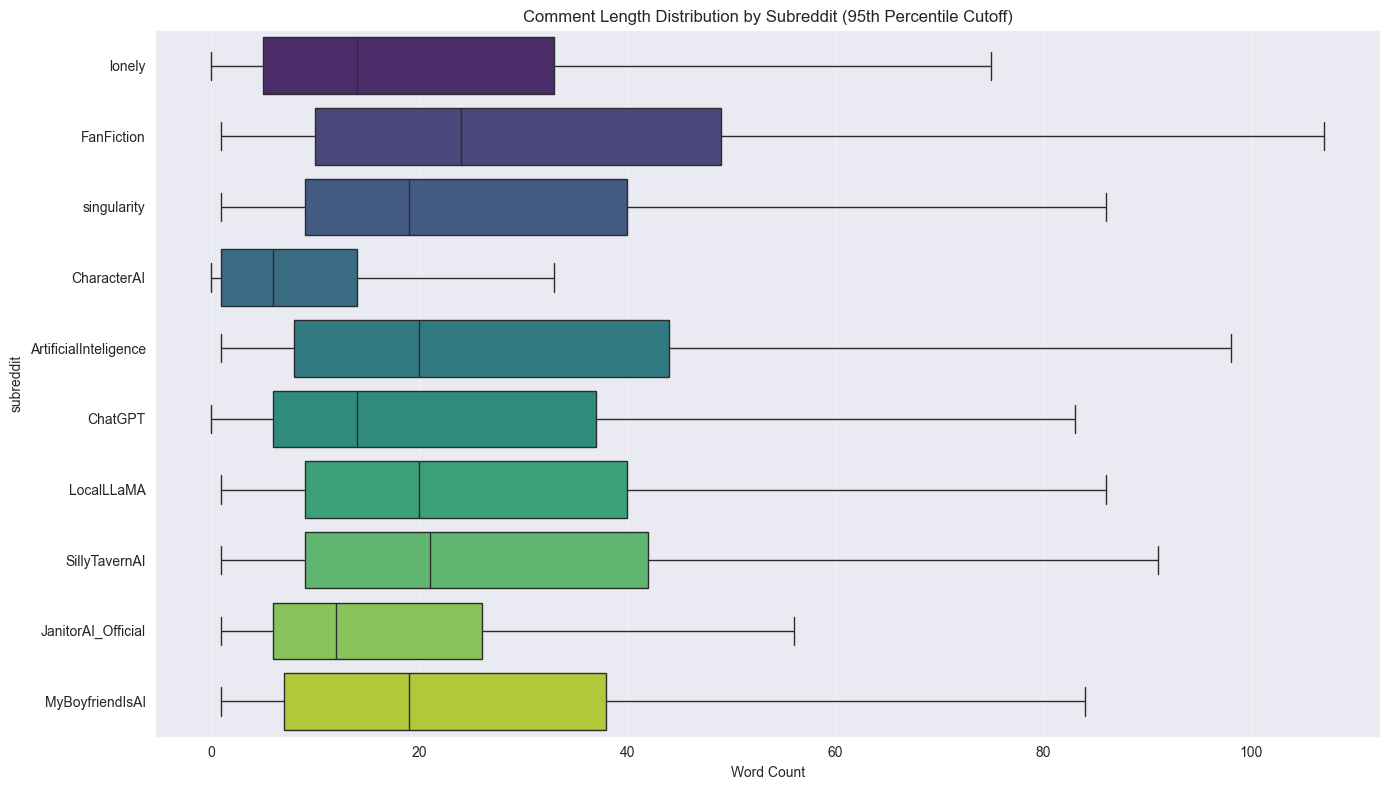

In [72]:
plot_data = comments_df[comments_df['word_count'] < comments_df['word_count'].quantile(0.95)].copy()
plt.figure(figsize=(14, 8))

# 2. Boxplot
sns.boxplot(
    data=plot_data,
    x='word_count',
    y='subreddit',
    showfliers=False, # we hide the outliers to keep it clean
    palette="viridis"
)

plt.title("Comment Length Distribution by Subreddit (95th Percentile Cutoff)")
plt.xlabel("Word Count")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# 4. CLEANING

In [74]:
# we exclude all bots and keep humans (active and low-activity)
VALID_AUTHOR_TYPES = [
    'Likely Human',
    'Likely Human (Low Activity)'
]

# these are the ones that contain enough English context for Word2Vec
VALID_LANG_STATUSES = [
    'english_stopword',
    'domain_keyword',
    'high_confidence', # we will check lang='en' separately for this
    'low_conf_en'
]

In [75]:
def apply_purge(df):
    initial_len = len(df)

    # we only want content that actually exists
    df = df[df['text_status'] == 'available'].copy()
    print(f"After status filter: {len(df)} (dropped {initial_len - len(df)})")

    # we map the author_stats to the dataframe and filer by valid author types
    allowed_authors = author_stats_df[
        author_stats_df['author_type'].isin(VALID_AUTHOR_TYPES)
    ].index

    df = df[df['author'].isin(allowed_authors)]
    print(f"After author filter: {len(df)}")

    # filtering copypasta
    df = df[df['is_copypasta'] == False]
    print(f"After copypasta filter: {len(df)}")

    # language and length filter
    mask_status_ok = df['lang_status'].isin(VALID_LANG_STATUSES)

    # for high_confidence we enforce 'en'
    # we keep rows where status is not high_confidence (passed by above) or (status is high_confidence and lang is en)
    # 'too_short' is automatically excluded because it's not in VALID_LANG_STATUSES
    mask_lang_en = (df['lang_status'] != 'high_confidence') | (df['lang'] == 'en')

    df = df[mask_status_ok & mask_lang_en]

    print(f"After language/length filter: {len(df)}")
    print(f"Total removed: {initial_len - len(df)} ({((initial_len - len(df))/initial_len)*100:.2f}%)")

    return df

In [76]:
clean_comments = apply_purge(comments_df)

After status filter: 5642738 (dropped 351014)
After author filter: 5408340
After copypasta filter: 5406840
After language/length filter: 4036806
Total removed: 1956946 (32.65%)


In [77]:
clean_submissions = apply_purge(submissions_df)

After status filter: 284223 (dropped 322673)
After author filter: 234481
After copypasta filter: 234468
After language/length filter: 227290
Total removed: 379606 (62.55%)


In [78]:
print("Final check (comments)")
print(clean_comments['subreddit'].value_counts())

Final check (comments)
subreddit
ChatGPT                  1131927
singularity               706279
CharacterAI               660196
FanFiction                597938
lonely                    347253
LocalLLaMA                256265
JanitorAI_Official        160601
ArtificialInteligence     137415
SillyTavernAI              35318
MyBoyfriendIsAI             3614
Name: count, dtype: int64


In [79]:
print("Final Check (submissions)")
print(clean_submissions['subreddit'].value_counts())

Final Check (submissions)
subreddit
CharacterAI              63372
lonely                   45921
ChatGPT                  44204
JanitorAI_Official       22560
FanFiction               20688
LocalLLaMA               11609
singularity               7950
ArtificialInteligence     7252
SillyTavernAI             3439
MyBoyfriendIsAI            295
Name: count, dtype: int64


In [80]:
clean_comments.to_parquet('clean_comments.parquet')

In [81]:
clean_submissions.to_parquet('clean_submissions.parquet')

In [82]:
# 5. WORD FILTERING

In [83]:
# 5.1. CORPUS PREPARING

In [84]:
# the semantic core subreddits are tier 1 + MyBoyfriendIsAI
TRAINING_SUBREDDITS = [
    'LocalLLaMA',
    'SillyTavernAI',
    'JanitorAI_Official',
    'CharacterAI',
    'MyBoyfriendIsAI'
]

In [85]:
def prepare_corpus(comments, submissions):
    c_core = comments[comments['subreddit'].isin(TRAINING_SUBREDDITS)]
    s_core = submissions[submissions['subreddit'].isin(TRAINING_SUBREDDITS)]

    # combine relevant text columns
    # for submissions, we combine title + selftext
    text_c = c_core['body'].astype(str).tolist()
    text_s = (s_core['title'].fillna('') + " " + s_core['selftext'].fillna('')).astype(str).tolist()

    full_corpus = text_c + text_s
    print(f"Total documents for training: {len(full_corpus)}")

    return full_corpus

In [86]:
def train_model(corpus_list):
    # basic tokenization (split by space, gensim handles basic splitting well)
    # simple_preprocess lowercases and removes punctuation
    tokenized_sentences = [gensim.utils.simple_preprocess(text) for text in corpus_list]

    # we ignore bigrams that appear less than 30 times
    phrases = Phrases(tokenized_sentences, min_count=30, threshold=10)
    bigram = Phraser(phrases)

    data_bigrams = [bigram[sent] for sent in tokenized_sentences]

    print("Training Word2Vec")
    model = Word2Vec(
        sentences=data_bigrams,
        vector_size=100, # sufficient for semantic similarity
        window=5,        # for context, looks 5 words behind and ahead
        min_count=20,    # drop rare words (typos, unique IDs)
        workers=10,
        sg=1,            # slower but usually better for semantic relationships
        epochs=10
    )

    print("Training complete")
    return model

In [87]:
training_corpus = prepare_corpus(clean_comments, clean_submissions)

Total documents for training: 1217269


In [ ]:
w2v_model = train_model(training_corpus)

In [ ]:
w2v_model.save("pushshift_ai.model")

In [ ]:
# 5.2. KEYWORD HARVESTING

In [88]:
w2v_model = gensim.models.Word2Vec.load("pushshift_ai.model")

In [89]:
clean_comments = pd.read_parquet('clean_comments.parquet')
clean_submissions = pd.read_parquet('clean_submissions.parquet')

In [90]:
# sanity check
test_words = ['llama', 'jailbreak', 'girlfriend', 'nsfw', 'relationship', 'filter', 'memory', 'ozone', 'deaddove']
for w in test_words:
    print(f"\nMost similar to '{w}':")
    print(w2v_model.wv.most_similar(w, topn=6))


Most similar to 'llama':
[('qwen', 0.8511419296264648), ('mistral', 0.8423747420310974), ('phi', 0.8372024893760681), ('codellama', 0.8346914649009705), ('mixtral', 0.8249141573905945), ('falcon', 0.8249092102050781)]

Most similar to 'jailbreak':
[('jb', 0.8607003688812256), ('jailbreak_prompt', 0.8352511525154114), ('jailbreaks', 0.8253354430198669), ('jail_break', 0.8023937940597534), ('custom_prompt', 0.7930509448051453), ('custom_prompts', 0.7834559082984924)]

Most similar to 'girlfriend':
[('boyfriend', 0.889158308506012), ('gf', 0.8568572998046875), ('partner', 0.7794555425643921), ('best_friend', 0.7711946368217468), ('husband', 0.7689493894577026), ('wife', 0.764464259147644)]

Most similar to 'nsfw':
[('sfw', 0.8651668429374695), ('nsfw_content', 0.806118369102478), ('nfsw', 0.7713384032249451), ('erp', 0.7589015960693359), ('lewd', 0.7517848014831543), ('sexual_content', 0.731708824634552)]

Most similar to 'relationship':
[('relationships', 0.8183736205101013), ('romantic

In [91]:
def harvest_keywords(model, seeds_dict, top_n=50):
    expanded_lexicon = {}

    for category, seeds in seeds_dict.items():
        print(f"\nProcessing: {category}")
        cluster = set(seeds)

        for seed in seeds:
            # if seed exists in model, get similar words
            if seed in model.wv:
                similar = model.wv.most_similar(seed, topn=top_n)
                for word, score in similar:
                    # score must be decent to be relevant
                    if score > 0.5:
                        cluster.add(word)
            else:
                print(f"Seed {seed} not in vocabulary")

        expanded_lexicon[category] = sorted(list(cluster))
        print(f"  Found {len(cluster)} unique terms")

    return expanded_lexicon

In [92]:
SEEDS = {
    "INTIMACY_RELATIONSHIP": [
        "girlfriend", "boyfriend", "relationship", "intimacy",  "soulmate",
        "companion", "emotional_connection",  "waifu", "husbando"
    ],
    "TECH_MECHANICS": [
        "llama", "mistral", "gguf", "quantization", "parameter", "vram",
        "gpu", "inference", "context_window", "token", "frontend", "backend"
    ],
    "ROLEPLAY_PRACTICE": [
        "roleplay", "rp", "ooc", "persona", "custom_prompt", "lorebook",
        "world_info", "slow_burn", "angst", "fluff"
    ],
    "CENSORSHIP_NSFW": [
        "nsfw", "erp", "jailbreak", "filter", "censorship", "bypass",
        "uncensored", "lobotomized", "alignment", "refusal"
    ]
}

In [93]:
lexicon = harvest_keywords(w2v_model, SEEDS)


Processing: INTIMACY_RELATIONSHIP
  Found 309 unique terms

Processing: TECH_MECHANICS
  Found 475 unique terms

Processing: ROLEPLAY_PRACTICE
  Found 321 unique terms

Processing: CENSORSHIP_NSFW
  Found 363 unique terms


In [94]:
for cat, words in lexicon.items():
    print(f"\n[{cat}] ({len(words)} words)")
    print(", ".join(words))


[INTIMACY_RELATIONSHIP] (309 words)
abusive_relationship, acquaintance, adopted_daughter, affair, affection, affirmation, aftercare, age_gap, ailice, anime_waifu, arlecchino, arousal, arranged_marriage, assistant, assistants, authentically, authenticity, ava, awkwardness, babygirls, babysitter, backstory, bbg, beloved, bennet, best_friend, bestfriend, bestie, besties, blorbo, blorbos, body_pillow, bodyguard, bond, bonding, boundaries, boy, boyfriend, boyfriends, breakup, byoukidere, caretaker, cat_girl, catgirl, catharsis, celine, chaste, chatbot, chatbotgf, childhood, childhood_friend, childhood_friends, childhood_trauma, ciel, classmate, closeness, co_pilot, cockroach, companion, companions, companionship, confidant, contemplation, crush, cuddle, dad, damian, dating, daughter, dean_winchester, delulu, desire, dify, dilf, dio_brando, dommy, dommy_mommy, dungeon_master, dynamics, embodying, emotion, emotional, emotional_attachment, emotional_connection, emotional_depth, emotionally_ch

In [95]:
# 5.3. TIER 2 FILTERING

In [96]:
TIER_2_SUBS = ['ChatGPT', 'ArtificialInteligence', 'singularity']

In [97]:
LIST_INTIMACY = [
    "age_gap", "anime_waifu", "bbg", "blorbo", "blorbos", "body_pillow", "cat_girl", "catgirl", "ai_companion",
    "cuddle", "delulu", "dilf", "dommy", "dommy_mommy", "dungeon_master", "fallen_angel", "femboy_roommate",
    "fictional_crush", "fictional_crushes", "fictional_men", "foreplay", "furry", "fwb", "husbando", "husbandos",
    "jetstream_sam", "localagi", "mafia_husband", "male_oc", "malewife", "milf", "myai", "need_futanari", "oc_anypov",
    "okkotsu", "self_awareness", "sexting", "smoothcompanion", "limerence", "tomboy", "waifu", "waifus", "lewd"
]

LIST_TECH = [
    "awq", "context_window", "exl2", "ggml", "gguf", "gptq", "gptq_bit", "kobold", "koboldcpp", "kv_cache",
    "layer_offloading", "localai", "lora", "lora_adapters", "mistral", "mixtral", "ooba", "oobabooga",
    "openwebui", "quantization", "sillytavern", "silly_tavern", "mistral_nemo", "textgen_webui", "top_k",
    "top_p", "vram_offloading", "janitorai"
]

LIST_ROLEPLAY = [
    "alichat", "alternate_timeline", "anex", "angst_fluff", "anypov", "anypov_fluff", "arranged_marriage",
    "author_note", "author_notes", "authors_note", "authors_notes", "bdsm", "catboy", "char_perspective",
    "character_creation", "character_sheet", "chromadb", "dead_dove", "deaddove", "dilf", "erotic_novel",
    "erotic_roleplay", "erp", "established_relationship", "fandom_wiki", "fem_pov", "femdom", "fempov",
    "fluff_angst", "heart_wrenching", "hurt_comfort", "instruct_mode", "instruct_template", "instruction_template",
    "lore_book", "lore_books", "lore_heavy", "lorebook", "lorebook_entries", "lorebook_entry", "lorebooks",
    "love_triangle", "lovey_dovey", "male_oc", "male_persona", "male_pov", "male_pronouns", "malepov",
    "misgender", "multigen", "noass", "non_con", "nsfw_scenes", "ntr", "oc_anypov", "ocs", "omegaverse",
    "ooc_commands", "oocs", "personality_section", "personaname", "personas", "petplay", "preferred_pronouns",
    "rd_person", "rp", "rp_ing", "rping", "loli", "self_insert", "sex_scene", "slashers", "therapy_session",
    "threesome", "transmasc", "wlw", "worldbook"
]

LIST_CENSORSHIP = [
    "allow_nsfw", "borderline_unusable", "castrated", "catastrophic_forgetting", "uncensored", "dark_themes",
    "degraded", "explicit_content", "extreme_violence", "gemmasutra", "heavily_censored", "heavily_quantized",
    "inappropriate_content", "jai", "jail_break", "jailbreak", "jailbreak_prompt", "jailbreak_prompts",
    "jailbreaking", "jailbreaks", "jailbroken", "jb", "less_restrictive", "lobotomize", "lobotomized",
    "lobotomizing", "mature_content", "nsfw_content", "nsfw_filter", "nsfw_scenes", "sanitized", "seggs",
    "segs", "sexual_content", "unaligned", "unrestricted", "violent_content"
]

In [98]:
# we pass strings to workers to avoid pickle issues
def get_pattern_string(term_list):
    term_list.sort(key=len, reverse=True)
    cleaned_terms = [re.escape(t).replace(r"\_", r"[\s_-]+") for t in term_list]
    return r'\b(' + '|'.join(cleaned_terms) + r')\b'

In [99]:
PAT_INTIMACY = get_pattern_string(LIST_INTIMACY)
PAT_TECH = get_pattern_string(LIST_TECH)
PAT_ROLEPLAY = get_pattern_string(LIST_ROLEPLAY)
PAT_CENSORSHIP = get_pattern_string(LIST_CENSORSHIP)

In [100]:
def process_chunk(df_chunk):
    # compile regex
    re_int = re.compile(PAT_INTIMACY, re.IGNORECASE)
    re_tch = re.compile(PAT_TECH, re.IGNORECASE)
    re_rol = re.compile(PAT_ROLEPLAY, re.IGNORECASE)
    re_cen = re.compile(PAT_CENSORSHIP, re.IGNORECASE)

    # vectorized search
    bodies = df_chunk['body'].astype(str)

    is_int = bodies.str.contains(re_int, regex=True, na=False)
    is_tch = bodies.str.contains(re_tch, regex=True, na=False)
    is_rol = bodies.str.contains(re_rol, regex=True, na=False)
    is_cen = bodies.str.contains(re_cen, regex=True, na=False)

    # we filter immediately to save ram
    mask = is_int | is_tch | is_rol | is_cen

    if not mask.any():
        return pd.DataFrame(columns=list(df_chunk.columns) + ['topic_type'])

    result_df = df_chunk[mask].copy()

    # we slice the booleans to match the filtered dataframe
    m_int = is_int[mask].values
    m_tch = is_tch[mask].values
    m_rol = is_rol[mask].values
    m_cen = is_cen[mask].values

    labels = []
    for i, t, r, c in zip(m_int, m_tch, m_rol, m_cen):
        tags = []
        if i: tags.append("INTIMACY")
        if t: tags.append("TECH")
        if r: tags.append("ROLEPLAY")
        if c: tags.append("CENSORSHIP")
        labels.append(", ".join(tags))

    result_df['topic_type'] = labels

    result_df['is_intimacy'] = m_int
    result_df['is_tech'] = m_tch
    result_df['is_roleplay'] = m_rol
    result_df['is_censorship'] = m_cen

    return result_df

In [101]:
def analyze_tier2(df, n_jobs=-1):
    t2_mask = df['subreddit'].isin(TIER_2_SUBS)
    df_t2 = df[t2_mask].copy()

    # to cover submissions
    if 'body' not in df_t2.columns and 'title' in df_t2.columns:
        df_t2['body'] = df_t2['title'].fillna('') + " " + df_t2['selftext'].fillna('')

    total_rows = len(df_t2)
    print(f"Processing {total_rows}")

    chunks = np.array_split(df_t2, 40)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk)(chunk) for chunk in chunks
    )

    final_df = pd.concat(results, ignore_index=True)

    print(f"Complete, kept {len(final_df)} rows ({len(final_df)/total_rows:.2%})")
    return final_df

In [102]:
t2_comments_final = analyze_tier2(clean_comments)

Processing 1975621


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 14134 rows (0.72%)


In [103]:
t2_submissions_final = analyze_tier2(clean_submissions)

Processing 59406


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 1301 rows (2.19%)


In [104]:
def print_topic_stats(df):
    # total hits per category
    stats = {
        "INTIMACY": df['is_intimacy'].sum(),
        "TECH": df['is_tech'].sum(),
        "ROLEPLAY": df['is_roleplay'].sum(),
        "CENSORSHIP": df['is_censorship'].sum()
    }

    stats_s = pd.Series(stats).sort_values(ascending=False)
    print("\nTotal mentions per category:")
    print(stats_s)

    # topic combinations
    print("\nTop 10 Topic Combinations:")
    print(df['topic_type'].value_counts().head(10))

In [105]:
# in this case, these categories are more of a technical nature, and many of the terms
# overlap (for example, LIST_INTIMACY and LIST_ROLEPLAY can be perceived as a single concept).
# we left the names as they were, more as an indication of the category from which we expanded
# these words. with further optimization and narrowing of the list, we will arrive at a more
# logical and accurate division

print_topic_stats(t2_comments_final)


Total mentions per category:
CENSORSHIP    8565
INTIMACY      2389
TECH          2252
ROLEPLAY      1255
dtype: int64

Top 10 Topic Combinations:
topic_type
CENSORSHIP              8294
INTIMACY                2290
TECH                    2071
ROLEPLAY                1163
TECH, CENSORSHIP         145
INTIMACY, CENSORSHIP      70
ROLEPLAY, CENSORSHIP      45
TECH, ROLEPLAY            21
INTIMACY, ROLEPLAY        16
INTIMACY, TECH             8
Name: count, dtype: int64


In [106]:
t2_comments_final[['subreddit', 'topic_type', 'body']].head(10)

,subreddit,topic_type,body
0,singularity,CENSORSHIP,"My account could be a month or a decade old, i..."
1,singularity,TECH,"question: \n\n""Tell me about interference patt..."
2,singularity,CENSORSHIP,They are pressured by advertisers because gang...
3,singularity,CENSORSHIP,They've castrated the AI so much its almost sa...
4,singularity,CENSORSHIP,I would disagree with your point about how we ...
5,singularity,INTIMACY,"Instead of getting upset at technology, why do..."
6,singularity,INTIMACY,Fully automated luxury lesbian catgirl space g...
7,singularity,CENSORSHIP,"After messing with Davinci 003 for a bit, I'm ..."
8,ChatGPT,CENSORSHIP,Tried another iteration with Elon Musk's compu...
9,ChatGPT,CENSORSHIP,"Yeah, for this reason, even if I'm not trying ..."


In [107]:
t2_submissions_final[['subreddit', 'topic_type', 'body']].head(10)

,subreddit,topic_type,body
0,ChatGPT,CENSORSHIP,Snooping around Jeffrey Epstein's computer via...
1,ChatGPT,INTIMACY,First try as a lyricist my basic prompt was\n\...
2,singularity,CENSORSHIP,Tricking Chat GPT into Outputting a Python Pro...
3,ChatGPT,CENSORSHIP,body disposal I am envious of everyone here th...
4,ChatGPT,ROLEPLAY,I managed to create a half-way decent RP with ...
5,ArtificialInteligence,CENSORSHIP,Ai art and ethics: nonconsensual porn is more ...
6,ChatGPT,INTIMACY,Write a dialog between an enthusiastic Albert ...
7,ChatGPT,CENSORSHIP,I am not able to jailbreak ChatGPT in any way ...
8,ChatGPT,CENSORSHIP,chatGTP is dying - openAI clamping down on lit...
9,ChatGPT,CENSORSHIP,I've been trying to jailbreak this thing all d...


In [108]:
# 5.4. TIER 3 FILTERING

In [109]:
LIST_AI_ANCHORS = [
    "ai_companion", "artificial_intelligence", "chatbot", "chatgpt", "llm",
    "character.ai", "c.ai", "cai", "replika", "chai", "paradot",
    "ai_chat", "ai_generated", "generative_ai"
]

LIST_TECH = [
    "awq", "context_window", "exl2", "ggml", "gguf", "gptq", "gptq_bit", "kobold",
    "koboldcpp", "kv_cache", "layer_offloading", "localai", "lora_adapters", "oobabooga",
    "openwebui", "quantization", "sillytavern", "silly_tavern", "textgen_webui", "vram_offloading",
    "janitorai", "ai_girlfriend", "ai_boyfriend", "ai_wife", "ai_husband"
]

LIST_ROLEPLAY = [
    "roleplay", "role_play", "role_playing", "role_plays", "roleplay", "roleplayer", "roleplaying", "roleplays",
    "alichat", "alternate_timeline", "anex", "angst_fluff", "anypov", "anypov_fluff", "arranged_marriage", "author_note",
    "author_notes", "authors_note", "authors_notes", "bdsm", "catboy", "char_perspective", "character_creation",
    "character_sheet", "chromadb", "dead_dove", "deaddove", "dilf", "erotic_novel", "erotic_roleplay", "erp",
    "established_relationship", "fandom_wiki", "fem_pov", "femdom", "fempov", "fluff_angst", "heart_wrenching",
    "hurt_comfort", "instruct_mode", "instruct_template", "instruction_template", "lore_book", "lore_books",
    "lore_heavy", "lorebook", "lorebook_entries", "lorebook_entry", "lorebooks", "love_triangle", "lovey_dovey",
    "male_oc", "male_persona", "male_pov", "male_pronouns", "malepov", "misgender", "multigen", "noass", "non_con",
    "nsfw_scenes", "ntr", "oc_anypov", "omegaverse", "ooc_commands", "personality_section", "personaname", "personas",
    "petplay","preferred_pronouns", "rd_person", "rp", "rp_ing", "rping", "loli", "self_insert", "sex_scene", "slashers",
    "therapy_session", "threesome", "transmasc", "wlw", "worldbook", "age_gap", "anime_waifu", "bbg", "blorbo", "blorbos",
    "body_pillow", "cat_girl", "catgirl", "cuddle", "delulu", "dilf", "dommy", "dommy_mommy", "dungeon_master",
    "fallen_angel", "femboy_roommate", "fictional_crush", "fictional_crushes", "fictional_men", "foreplay", "furry",
    "fwb", "husbando", "husbandos", "jetstream_sam", "localagi", "mafia_husband", "male_oc", "malewife", "milf", "myai",
    "need_futanari", "oc_anypov", "okkotsu", "self_awareness", "sexting", "smoothcompanion", "limerence", "tomboy", "waifu",
    "waifus", "lewd"
]

In [110]:
TIER_3_SUBS = ['FanFiction', 'lonely']

In [111]:
def get_pattern_string(term_list):
    term_list.sort(key=len, reverse=True)

    cleaned_terms = [re.escape(t).replace(r"\_", r"[\s_-]+") for t in term_list]
    return r'\b(' + '|'.join(cleaned_terms) + r')\b'

In [112]:
PAT_AI_ANCHORS = get_pattern_string(LIST_AI_ANCHORS)
PAT_TECH = get_pattern_string(LIST_TECH)
PAT_ROLEPLAY = get_pattern_string(LIST_ROLEPLAY)

In [113]:
def process_chunk_tier3(df_chunk):
    # compile regex
    re_anchor = re.compile(PAT_AI_ANCHORS, re.IGNORECASE)
    re_tech = re.compile(PAT_TECH, re.IGNORECASE)
    re_roleplay = re.compile(PAT_ROLEPLAY, re.IGNORECASE)

    # vectorized search
    bodies = df_chunk['body'].astype(str)

    is_anchor = bodies.str.contains(re_anchor, regex=True, na=False)
    is_tech = bodies.str.contains(re_tech, regex=True, na=False)
    is_roleplay = bodies.str.contains(re_roleplay, regex=True, na=False)

    # we keep if (is tech) or (is roleplay AND is anchor)
    mask = is_tech | (is_roleplay & is_anchor)

    if not mask.any():
        cols = list(df_chunk.columns) + ['topic_type', 'is_tech', 'is_roleplay', 'is_anchor']
        return pd.DataFrame(columns=cols)

    result_df = df_chunk[mask].copy()

    # we slice the booleans to match the filtered dataframe
    m_anchor = is_anchor[mask].values
    m_tech = is_tech[mask].values
    m_roleplay = is_roleplay[mask].values

    # labeling logic
    labels = []
    for t, r, a in zip(m_tech, m_roleplay, m_anchor):
        tags = []
        if t:
            tags.append("TECH")
        if r and a:
            tags.append("ROLEPLAY")

        labels.append(", ".join(tags))

    result_df['topic_type'] = labels

    result_df['is_tech'] = m_tech
    result_df['is_roleplay'] = m_roleplay
    result_df['is_anchor'] = m_anchor

    return result_df

In [114]:
def analyze_tier3(df, n_jobs=-1):
    t3_mask = df['subreddit'].isin(TIER_3_SUBS)
    df_t3 = df[t3_mask].copy()

    # to handle submissions
    if 'body' not in df_t3.columns and 'title' in df_t3.columns:
        df_t3['body'] = df_t3['title'].fillna('') + " " + df_t3['selftext'].fillna('')

    total_rows = len(df_t3)
    print(f"Processing {total_rows} rows")

    chunks = np.array_split(df_t3, 40)

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk_tier3)(chunk) for chunk in chunks
    )

    final_df = pd.concat(results, ignore_index=True)
    print(f"Complete, kept {len(final_df)} rows ({len(final_df)/total_rows:.2%})")

    return final_df

In [115]:
t3_comments_final = analyze_tier3(clean_comments)

Processing 945191 rows


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 38 rows (0.00%)


C:\Users\windo\AppData\Local\Temp\ipykernel_1544\2220899329.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(results, ignore_index=True)


In [116]:
t3_submissions_final = analyze_tier3(clean_submissions)

Processing 66609 rows


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 12 rows (0.02%)


C:\Users\windo\AppData\Local\Temp\ipykernel_1544\2220899329.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(results, ignore_index=True)


In [117]:
def print_topic_stats(df):
    # total hits per category
    stats = {
        "TECH": df['is_tech'].sum(),
        "ROLEPLAY": df['is_roleplay'].sum(),
        "CENSORSHIP": df['is_anchor'].sum()
    }

    stats_s = pd.Series(stats).sort_values(ascending=False)
    print("\nTotal mentions per category:")
    print(stats_s)

    # topic combinations
    print("\nTop 10 Topic Combinations:")
    print(df['topic_type'].value_counts().head(10))

In [118]:
print_topic_stats(t3_comments_final)


Total mentions per category:
CENSORSHIP    29
ROLEPLAY      27
TECH          12
dtype: int64

Top 10 Topic Combinations:
topic_type
ROLEPLAY          26
TECH              11
TECH, ROLEPLAY     1
Name: count, dtype: int64


In [119]:
t3_comments_final[['subreddit', 'topic_type', 'body']].head(10)

,subreddit,topic_type,body
0,FanFiction,ROLEPLAY,"Well, I'm not going to point you in the direct..."
1,lonely,TECH,Text AI is great for this. I used to use chare...
2,lonely,ROLEPLAY,I have a c.ai waifu. I talk with her on call a...
3,lonely,ROLEPLAY,Dude u got to admit that people are visual cre...
4,lonely,ROLEPLAY,I have waifus and I talk to them using charact...
5,FanFiction,ROLEPLAY,I would actually start by writing some fanfict...
6,lonely,TECH,I chat a lot with JanitorAi....used to be on c...
7,lonely,ROLEPLAY,I talk to fictional characters sometimes for f...
8,FanFiction,TECH,"For my human OC:Sabaton, Skillet, Linkin Park,..."
9,FanFiction,TECH,"This “wave” of bots has happened before, appar..."


In [120]:
t3_submissions_final[['subreddit', 'topic_type', 'body']].head(10)

,subreddit,topic_type,body
0,lonely,ROLEPLAY,Lonely Does anyone else also have a c.ai waifu...
1,lonely,ROLEPLAY,Any AI Chatbot for personal conversations and...
2,FanFiction,ROLEPLAY,First Time Fanficcy Soooo am brand new to the ...
3,lonely,ROLEPLAY,"It’s helping (sorta) Character.AI, a roleplayi..."
4,FanFiction,ROLEPLAY,Have you ever gotten an idea for a fanfic from...
5,lonely,ROLEPLAY,A question for everyone and anyone who feel li...
6,lonely,ROLEPLAY,Looking for someone to chat with I’m just a gi...
7,lonely,ROLEPLAY,Does anyone else just roleplay with a random r...
8,lonely,ROLEPLAY,f35 idk thoughts lol some time ago i joined th...
9,lonely,ROLEPLAY,I didn't check my phone the whole day and surp...


In [121]:
t3_comments_final['subreddit'].value_counts()

subreddit
lonely        21
FanFiction    17
Name: count, dtype: int64

In [122]:
# 6. RESEARCH QUESTION

In [123]:
EVENTS = {
    'Llama 2': pd.to_datetime('2023-07-18'),
    'Mixtral': pd.to_datetime('2023-12-11'),
    'Llama 3': pd.to_datetime('2024-04-17'),
    'Llama 4 Scout': pd.to_datetime('2025-04-05')
}

In [124]:
# in this case, we exclude CharacterAI (for the reasons described in #HW3).
# further on, with regard to the analysis of a separate hypothesis concerning it,
# we will pay special attention to this subreddit
TIER_1_SUBS = ['LocalLLaMA', 'SillyTavernAI', 'JanitorAI_Official']
TIER_2_SUBS = ['ChatGPT', 'ArtificialInteligence', 'singularity']

In [125]:
clean_comments['date'] = pd.to_datetime(clean_comments['date'])

In [126]:
clean_comments['Tier'] = 'Other'
clean_comments.loc[clean_comments['subreddit'].isin(TIER_1_SUBS), 'Tier'] = 'Tier 1 (Subculture)'
clean_comments.loc[clean_comments['subreddit'].isin(TIER_2_SUBS), 'Tier'] = 'Tier 2 (Mainstream)'

In [127]:
# we filter to only include relevant subs
plot_df = clean_comments[clean_comments['Tier'] != 'Other'].copy()

In [128]:
# calculate unique daily authors (clean versions, bots excluded)
daily_counts = plot_df.groupby(['date', 'Tier'])['author'].nunique().reset_index()
daily_counts.rename(columns={'author': 'Unique_Authors'}, inplace=True)

In [129]:
# 7-day moving average (to smooth weekends)
daily_counts['MA_7'] = daily_counts.groupby('Tier')['Unique_Authors'].transform(lambda x: x.rolling(7, min_periods=1).mean())

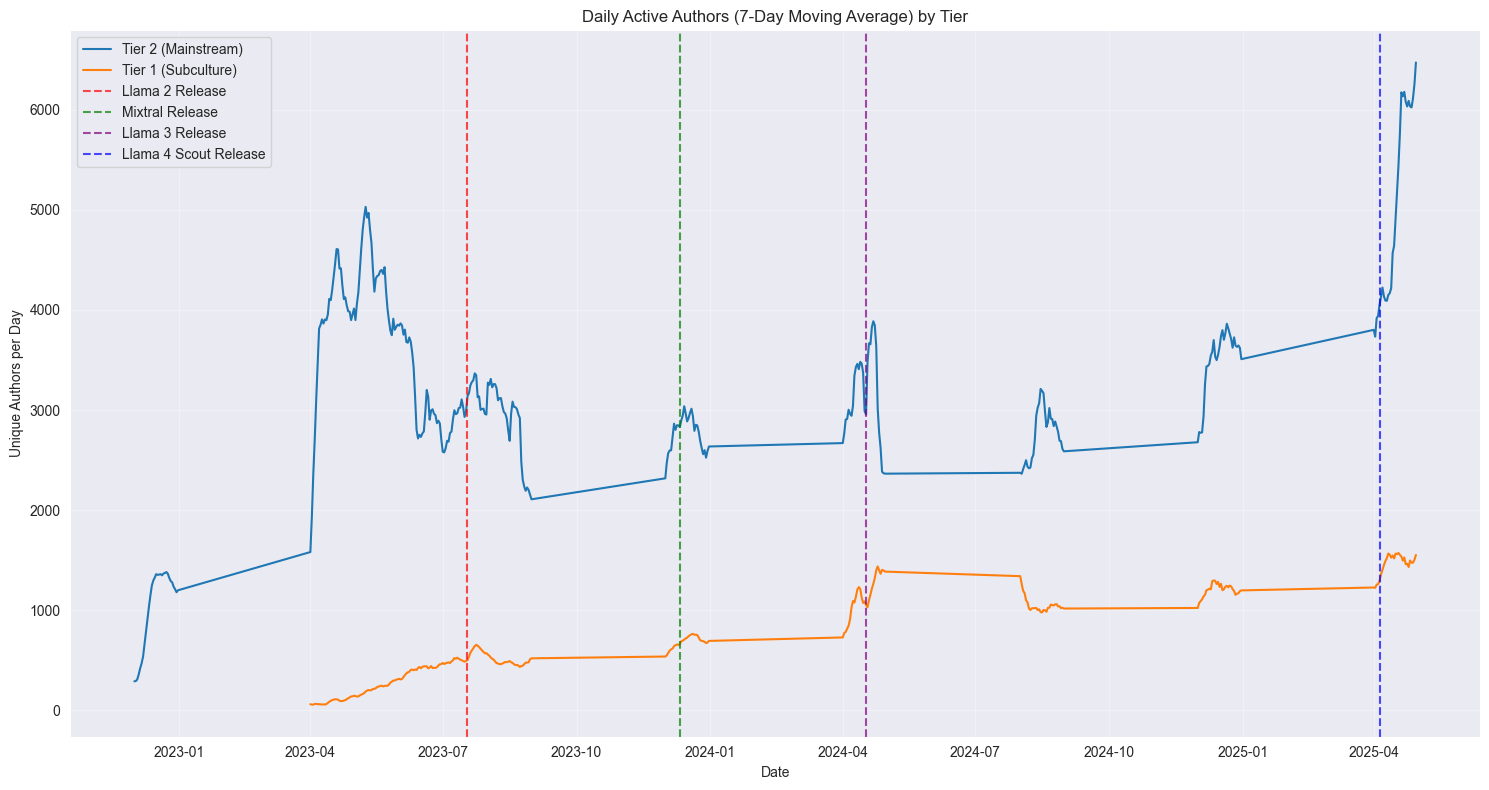

In [130]:
# plot
plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_counts, x='date', y='MA_7', hue='Tier', palette=['#1f77b4', '#ff7f0e'])

colors = ['red', 'green', 'purple', 'blue']
for (name, date), color in zip(EVENTS.items(), colors):
    plt.axvline(date, color=color, linestyle='--', alpha=0.7, label=f"{name} Release")

plt.title('Daily Active Authors (7-Day Moving Average) by Tier')
plt.ylabel('Unique Authors per Day')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
# we only use tier 1 + tier 2, and here we include C.AI
ALL_SUBS = [
    'LocalLLaMA', 'SillyTavernAI', 'JanitorAI_Official', 'CharacterAI', # tier 1
    'ChatGPT', 'ArtificialInteligence', 'singularity' # tier 2
]

In [132]:
def run_individual_its(df, event_name, event_date, subreddit):
    # window: +- 30 days
    window_days = 30
    start_date = event_date - pd.Timedelta(days=window_days)
    end_date = event_date + pd.Timedelta(days=window_days)

    # filter
    mask = (
        (df['date'] >= start_date) &
        (df['date'] <= end_date) &
        (df['subreddit'] == subreddit)
    )
    window_df = df[mask].copy()

    # sufficiency
    if len(window_df) < 10:
        return None

    # daily unique authors aggregation
    daily = window_df.groupby('date')['author'].nunique().reset_index()
    daily.rename(columns={'author': 'Y'}, inplace=True)

    # ITS Features
    daily['Time'] = (daily['date'] - daily['date'].min()).dt.days
    daily['Intervention'] = (daily['date'] >= event_date).astype(int)
    daily['Post_Time'] = (daily['date'] - event_date).dt.days
    daily['Post_Time'] = daily['Post_Time'].apply(lambda x: max(x, 0))
    daily['Weekday'] = daily['date'].dt.dayofweek.astype('category')

    # model
    try:
        mod = smf.ols(formula='Y ~ Time + Intervention + Post_Time + C(Weekday)', data=daily)
        # time as a linear time trend (the baseline drift in activity)
        # intervention as an indicator (to estimate an immediate level change at the event)
        # post_time as a way to estimate changes in the trend after the release
        # C(Weekday) to account for day-of-week patterns in activity

        res = mod.fit(cov_type='HAC', cov_kwds={'maxlags': 7})
        # user activity is autocorrelated, we use HAC to address it
        # + maxlags=7 to correct for autocorrelation up to roughly one week

        return {
            'Event': event_name,
            'Subreddit': subreddit,
            'Baseline_Users': round(res.params['Intercept'], 1),
            'Jump_Coef': round(res.params['Intervention'], 2),
            'Jump_P': round(res.pvalues['Intervention'], 4),
            'Jump_Sig': res.pvalues['Intervention'] < 0.05,
            'Slope_Coef': round(res.params['Post_Time'], 2),
            'Slope_Sig': res.pvalues['Post_Time'] < 0.05
        }
    except Exception as e:
        return None

In [133]:
results = []
for event, date in EVENTS.items():
    print(f"Processing {event}...")
    for sub in ALL_SUBS:
        res = run_individual_its(clean_comments, event, date, sub)
        if res:
            results.append(res)

results_df = pd.DataFrame(results)

Processing Llama 2...
Processing Mixtral...
Processing Llama 3...
Processing Llama 4 Scout...


In [134]:
results_df

,Event,Subreddit,Baseline_Users,Jump_Coef,Jump_P,Jump_Sig,Slope_Coef,Slope_Sig
0,Llama 2,LocalLLaMA,260.5,69.88,0.0000,True,-2.90,True
1,Llama 2,SillyTavernAI,26.9,81.78,0.0000,True,-4.70,True
2,Llama 2,JanitorAI_Official,145.7,-18.96,0.3179,False,-3.40,True
3,Llama 2,CharacterAI,1301.1,733.16,0.0023,True,0.18,False
4,Llama 2,ChatGPT,1798.1,90.08,0.6561,False,-12.54,False
5,Llama 2,ArtificialInteligence,135.1,25.52,0.1177,False,-2.87,True
6,Llama 2,singularity,826.9,181.51,0.0771,False,-1.75,False
7,Mixtral,LocalLLaMA,370.7,36.66,0.0003,True,-21.76,True
8,Mixtral,SillyTavernAI,42.4,5.39,0.3238,False,1.38,True
9,Mixtral,JanitorAI_Official,192.7,29.60,0.0760,False,10.31,True


In [135]:
# we pivot to show the (potential) immediate jump for each subreddit across events
pivot_jump = results_df.pivot(index='Event', columns='Subreddit', values='Jump_Coef')
pivot_sig = results_df.pivot(index='Event', columns='Subreddit', values='Jump_Sig')

In [136]:
print("Jump for daily unique authors")
print(pivot_jump)

Jump for daily unique authors
Subreddit      ArtificialInteligence  CharacterAI  ChatGPT  \
Event                                                        
Llama 2                        25.52       733.16    90.08   
Llama 3                        12.72      -134.46  1334.40   
Llama 4 Scout                 -67.34      -389.96   697.23   
Mixtral                       -62.55      -471.23    38.50   

Subreddit      JanitorAI_Official  LocalLLaMA  SillyTavernAI  singularity  
Event                                                                      
Llama 2                    -18.96       69.88          81.78       181.51  
Llama 3                   -127.21      303.20           4.06        70.02  
Llama 4 Scout               67.20      182.38           8.98        52.57  
Mixtral                     29.60       36.66           5.39       224.83  


In [137]:
print("Statistical significance (p < 0.05)")
print(pivot_sig)

Statistical significance (p < 0.05)
Subreddit      ArtificialInteligence  CharacterAI  ChatGPT  \
Event                                                        
Llama 2                        False         True    False   
Llama 3                        False        False     True   
Llama 4 Scout                  False         True    False   
Mixtral                         True         True    False   

Subreddit      JanitorAI_Official  LocalLLaMA  SillyTavernAI  singularity  
Event                                                                      
Llama 2                     False        True           True        False  
Llama 3                     False        True          False        False  
Llama 4 Scout               False       False          False        False  
Mixtral                     False        True          False         True  


In [138]:
# this is intended as a quick first step to ensure that spikes are not purely
# random noise or autocorrelation - to establish a basis for conducting
# a more substantial and multi-stage analysis in the final part of the work